In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [2]:
import os

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModelAndWeights


DATA_DIR = os.getenv('DATA_DIR')
TRAINING_DIR = os.getenv('TRAINING_DIR')

config = Configuration(os.path.join(TRAINING_DIR, 'paraff/20241201-midiseq-paraff-se-ly+cc-d256-l8-dw0.02'), volatile=True)
#train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
model, chk = loadModelAndWeights(config, config['best'], postfix='JitEnc')
model.eval()
model


/home/camus/work/deep-starry/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-13 18:16:39.264005: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-13 18:16:39.264049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-13 18:16:39.265316: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-13 18:16:39.273374: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow b

SeqShareSEJitEnc(
  (word_emb): Embedding(324, 256, padding_idx=0)
  (word_prj): Linear(in_features=256, out_features=324, bias=False)
  (latent_prj): Linear(in_features=256, out_features=256, bias=False)
  (latent_emb): Linear(in_features=256, out_features=256, bias=True)
  (position_enc): PositionalEncoding()
  (layer_norm): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
  (attention): AttentionStack(
    (layer_stack): ModuleList(
      (0-7): 8 x EncoderLayer(
        (slf_attn): MultiHeadAttention(
          (w_qs): Linear(in_features=256, out_features=256, bias=False)
          (w_ks): Linear(in_features=256, out_features=256, bias=False)
          (w_vs): Linear(in_features=256, out_features=256, bias=False)
          (fc): Linear(in_features=256, out_features=256, bias=False)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (layer_norm): LayerNor

In [3]:
data, = loadDataset(config, data_dir=DATA_DIR, device='cpu', splits='0/1')
it = iter(data)

batch = next(it)
batch

{'summary': tensor([[-2.5298,  1.6278,  0.0395,  ...,  1.5188,  0.7176, -0.5361],
         [-1.9059,  0.6116,  1.1287,  ..., -0.9592,  1.0372, -0.9585],
         [ 0.0486, -0.4749,  1.5414,  ...,  0.5503,  1.3355,  0.1226],
         ...,
         [ 0.6640, -0.8382, -0.0306,  ..., -0.7407,  0.7383, -1.2218],
         [-0.0798,  0.9473,  0.1012,  ...,  0.6817,  1.6028, -1.3798],
         [ 1.0934, -1.2052,  0.9019,  ..., -0.1106,  0.3884, -0.2628]]),
 'seq': tensor([[  1,   2, 297,  ...,   0,   0,   0],
         [  1,   2, 299,  ...,   0,   0,   0],
         [  1,   2, 295,  ...,   0,   0,   0],
         ...,
         [  1,   2, 301,  ...,   0,   0,   0],
         [  1,   2, 297,  ...,   0,   0,   0],
         [  1,   2, 294,  ...,   0,   0,   0]]),
 'decoding_mask': tensor([[ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         ...,
         [ True,  True,  True,  ..

In [4]:
batch['seq'].shape

torch.Size([48, 249])

In [5]:
import torch


with torch.no_grad():
	sums = model(batch['seq'][:, 1:])

sums.shape

torch.Size([48, 256])

In [6]:
sums_norm = sums / sums.norm(dim=-1).unsqueeze(-1)
sums_norm.shape

torch.Size([48, 256])

In [7]:
target = batch['summary']
target_norm = target / target.norm(dim=-1).unsqueeze(-1)
target_norm.shape

torch.Size([48, 256])

In [8]:
product = torch.matmul(sums_norm, target_norm.transpose(0, 1))
product.shape

torch.Size([48, 48])

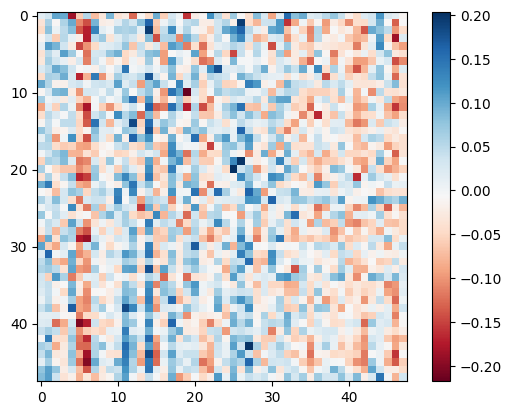

In [9]:
from matplotlib import pyplot as plt
%matplotlib inline


plt.imshow(product, cmap='RdBu')
plt.colorbar()
plt.show()